In [4]:
!pip install psycopg2-binary sqlalchemy


In [6]:
!pip install pyngrok psycopg2-binary


In [7]:
from pyngrok import ngrok
import psycopg2

In [9]:
!pip install pyngrok
from pyngrok import conf

# Remplace par ton vrai authtoken
conf.get_default().auth_token = "3CGZWgQFeeehorOXrBENmiFR6oW_3ZzUYkktNGWq9gBuGb8zZ"


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import plotly.express as px

In [12]:
# Étape A Data Preparation

import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, f_classif

# Charger les données fact-membership et dim-unit et fusion
fact_membership = pd.read_csv("fact-membership.csv")
dim_unit = pd.read_csv("dim-unit.csv")

df = fact_membership.merge(dim_unit, on="id_unit", how="left")


df_clean = df.drop(columns=["id_fact_member", "id_unit"])

encoder = LabelEncoder()
df_clean["unit_name_encoded"] = encoder.fit_transform(df_clean["unit_name"])
df_clean["season_encoded"] = encoder.fit_transform(df_clean["season"])

# Feature Engineering créer une variable binaire "fidélisation élevée"
df_clean["high_fidelity"] = (df_clean["taux_fidelisation"] >= 90).astype(int)

# Normalisation et  Sélection de variables
scaler = StandardScaler()
num_cols = ["nb_members", "nb_leaders", "taux_fidelisation", "taux_evolution"]
df_clean[num_cols] = scaler.fit_transform(df_clean[num_cols])

X = df_clean[["nb_members", "nb_leaders", "taux_fidelisation", "taux_evolution",
              "unit_name_encoded", "season_encoded"]]
y = df_clean["high_fidelity"]

selector = SelectKBest(score_func=f_classif, k=4)
X_selected = selector.fit_transform(X, y)

print("Selected features:", X.columns[selector.get_support()])


Selected features: Index(['nb_members', 'nb_leaders', 'taux_fidelisation', 'taux_evolution'], dtype='object')


In [13]:

#B Model Understanding

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Split train/test
X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.3, random_state=42)

#  Modèle 1 Logistic Regression
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)


#  Mode 2 Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

print("Logistic Regression train score:", log_reg.score(X_train, y_train))
print("Random Forest train score:", rf.score(X_train, y_train))
print("Logistic Regression test score:", log_reg.score(X_test, y_test))
print("Random Forest test score:", rf.score(X_test, y_test))


Logistic Regression train score: 1.0
Random Forest train score: 1.0
Logistic Regression test score: 1.0
Random Forest test score: 1.0


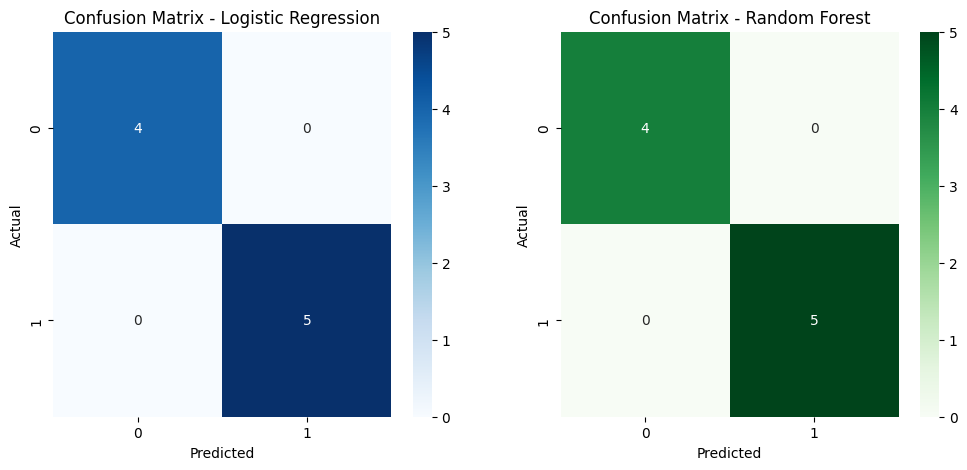

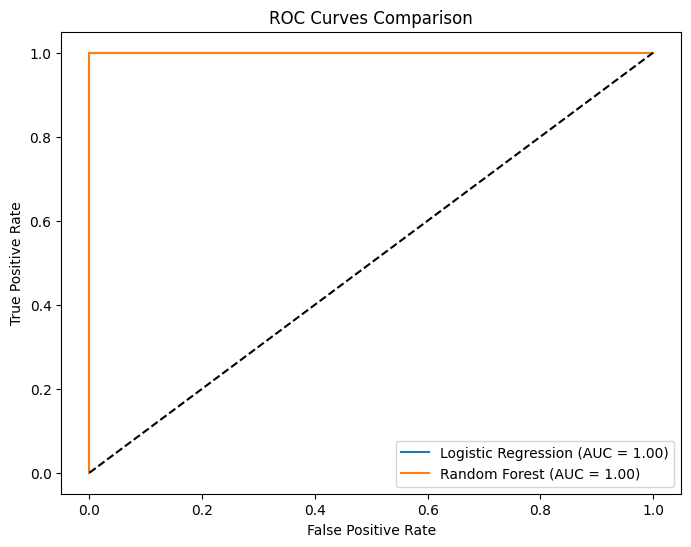

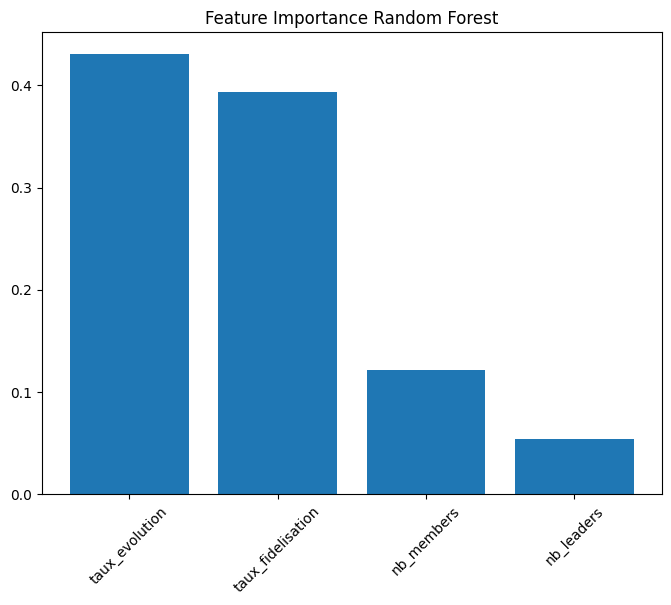

In [14]:

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc
import numpy as np

# Matrice de confusion
y_pred_log = log_reg.predict(X_test)
y_pred_rf = rf.predict(X_test)

cm_log = confusion_matrix(y_test, y_pred_log)
cm_rf = confusion_matrix(y_test, y_pred_rf)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(cm_log, annot=True, fmt="d", cmap="Blues", ax=ax[0])
ax[0].set_title("Confusion Matrix - Logistic Regression")
ax[0].set_xlabel("Predicted")
ax[0].set_ylabel("Actual")

sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens", ax=ax[1])
ax[1].set_title("Confusion Matrix - Random Forest")
ax[1].set_xlabel("Predicted")
ax[1].set_ylabel("Actual")

plt.show()

# Courbes ROC
y_prob_log = log_reg.predict_proba(X_test)[:,1]
y_prob_rf = rf.predict_proba(X_test)[:,1]

fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

roc_auc_log = auc(fpr_log, tpr_log)
roc_auc_rf = auc(fpr_rf, tpr_rf)

plt.figure(figsize=(8,6))
plt.plot(fpr_log, tpr_log, label=f"Logistic Regression (AUC = {roc_auc_log:.2f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {roc_auc_rf:.2f})")
plt.plot([0,1],[0,1],"k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves Comparison")
plt.legend(loc="lower right")
plt.show()

# Importance des features Random Forest
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(8,6))
plt.bar(range(X_selected.shape[1]), importances[indices], align="center")
plt.xticks(range(X_selected.shape[1]), X.columns[selector.get_support()][indices], rotation=45)
plt.title("Feature Importance Random Forest")
plt.show()


In [15]:
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# GridSearch pour Random Forest
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10]
}
grid_rf = GridSearchCV(RandomForestClassifier(random_state=42, class_weight="balanced"),
                       param_grid, cv=5, scoring='f1')
grid_rf.fit(X_train, y_train)
print("Best RF params:", grid_rf.best_params_)

# Validation croisée Logistic Regression
scores = cross_val_score(LogisticRegression(class_weight="balanced"), X_selected, y, cv=5, scoring='f1')
print("Logistic Regression CV F1-score:", scores.mean())

# Comparaison des métriques sur test set
y_pred_log = log_reg.predict(X_test)
y_pred_rf = grid_rf.best_estimator_.predict(X_test)

print("Accuracy LogReg:", accuracy_score(y_test, y_pred_log))
print("Precision LogReg:", precision_score(y_test, y_pred_log))
print("Recall LogReg:", recall_score(y_test, y_pred_log))
print("F1 LogReg:", f1_score(y_test, y_pred_log))

print("Accuracy RF:", accuracy_score(y_test, y_pred_rf))
print("Precision RF:", precision_score(y_test, y_pred_rf))
print("Recall RF:", recall_score(y_test, y_pred_rf))
print("F1 RF:", f1_score(y_test, y_pred_rf))


Best RF params: {'max_depth': None, 'n_estimators': 50}
Logistic Regression CV F1-score: 0.96
Accuracy LogReg: 1.0
Precision LogReg: 1.0
Recall LogReg: 1.0
F1 LogReg: 1.0
Accuracy RF: 1.0
Precision RF: 1.0
Recall RF: 1.0
F1 RF: 1.0


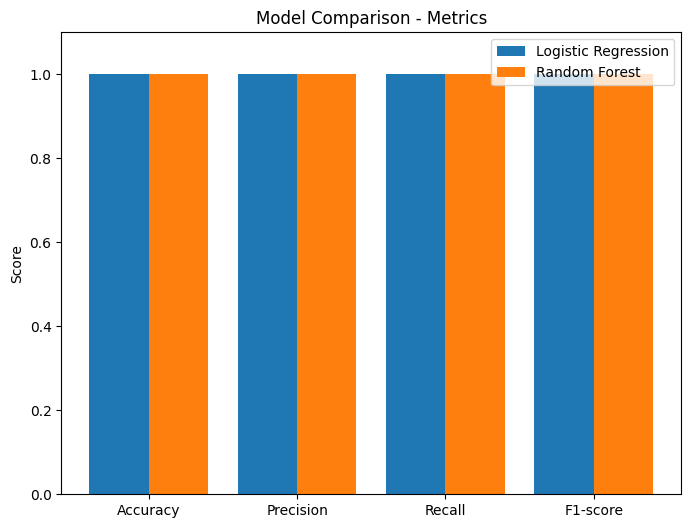

In [16]:
import matplotlib.pyplot as plt

metrics = ["Accuracy", "Precision", "Recall", "F1-score"]
log_scores = [accuracy_score(y_test, y_pred_log),
              precision_score(y_test, y_pred_log),
              recall_score(y_test, y_pred_log),
              f1_score(y_test, y_pred_log)]

rf_scores = [accuracy_score(y_test, y_pred_rf),
             precision_score(y_test, y_pred_rf),
             recall_score(y_test, y_pred_rf),
             f1_score(y_test, y_pred_rf)]

x = range(len(metrics))
plt.figure(figsize=(8,6))
plt.bar(x, log_scores, width=0.4, label="Logistic Regression", align="center")
plt.bar([i+0.4 for i in x], rf_scores, width=0.4, label="Random Forest", align="center")
plt.xticks([i+0.2 for i in x], metrics)
plt.ylim(0,1.1)
plt.ylabel("Score")
plt.title("Model Comparison - Metrics")
plt.legend()
plt.show()


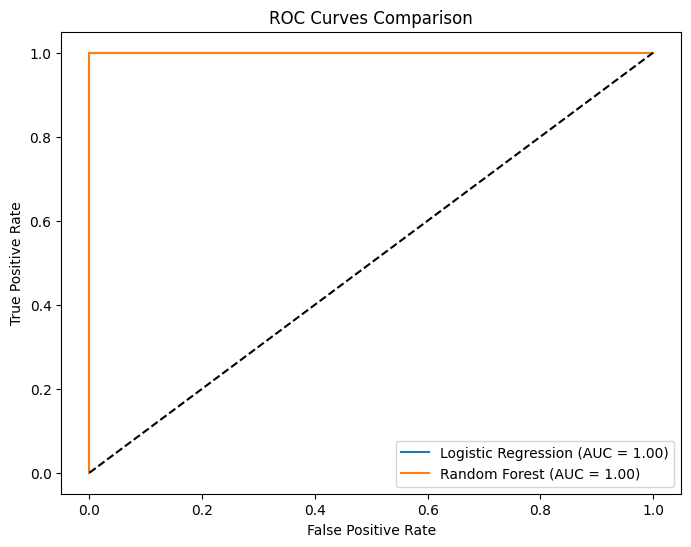

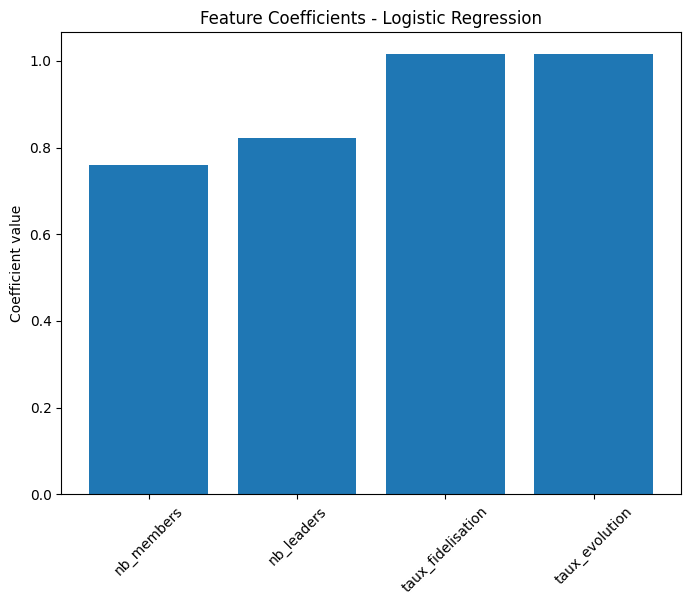

In [18]:
plt.figure(figsize=(8,6))
plt.plot(fpr_log, tpr_log, label=f"Logistic Regression (AUC = {roc_auc_log:.2f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {roc_auc_rf:.2f})")
plt.plot([0,1],[0,1],"k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves Comparison")
plt.legend(loc="lower right")
plt.show()

# importance des varaibles , Coefficients Logistic Regression

selected_features = X.columns[selector.get_support()]

coef = log_reg.coef_[0]

import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.bar(selected_features, coef)
plt.xticks(rotation=45)
plt.title("Feature Coefficients - Logistic Regression")
plt.ylabel("Coefficient value")
plt.show()



In [20]:
#regression  prédire le nombre de membres à partir des autres variables

import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

fact_membership = pd.read_csv("fact-membership.csv")
dim_unit = pd.read_csv("dim-unit.csv")

df = fact_membership.merge(dim_unit, on="id_unit", how="left")

# Encodage
encoder = LabelEncoder()
df["unit_name_encoded"] = encoder.fit_transform(df["unit_name"])
df["season_encoded"] = encoder.fit_transform(df["season"])

# Variables explicatives et cible
X = df[["nb_leaders", "taux_fidelisation", "taux_evolution",
        "unit_name_encoded", "season_encoded"]]
y = df["nb_members"]

# Normalisation Split train/test
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)


Linear Regression CV R² mean: 0.6205730843380777
Ridge Regression CV R² mean: 0.6222290457742328
Random Forest CV R² mean: 0.6615489075214491

Linear Regression Results:
MSE: 33.11843947880468
RMSE: 5.7548622467270825
MAE: 4.378277459973242
R²: 0.7161877276996214

Ridge Regression Results:
MSE: 22.613207031498437
RMSE: 4.755334586703488
MAE: 3.9091800687198397
R²: 0.8062135241693427

Random Forest Results:
MSE: 15.517744444444439
RMSE: 3.9392568391061324
MAE: 3.4699999999999993
R²: 0.8670189060516293


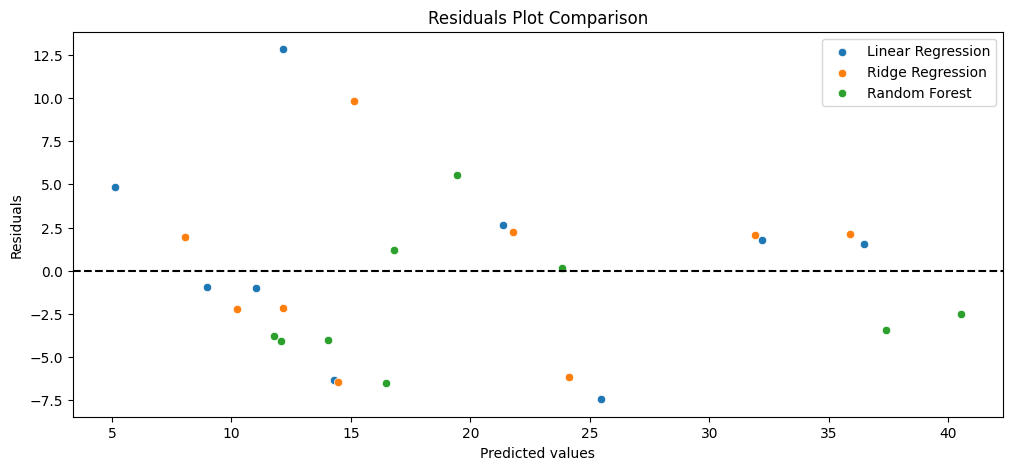

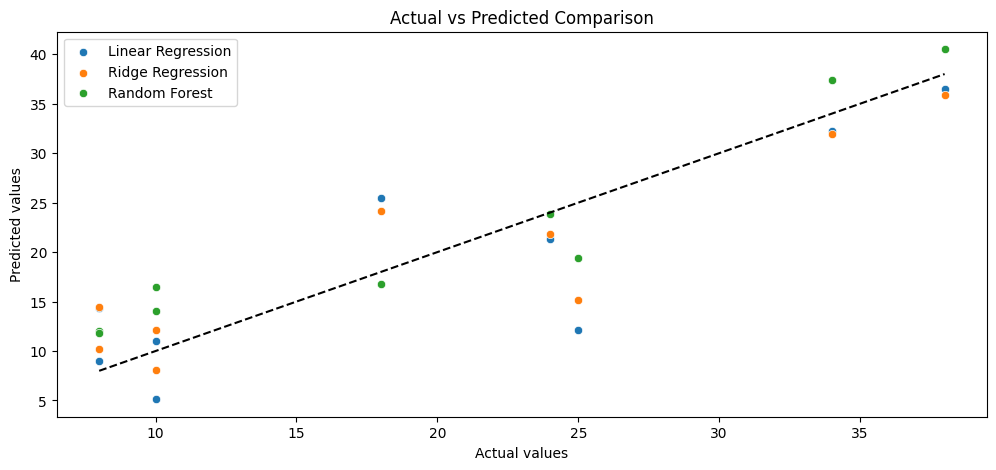

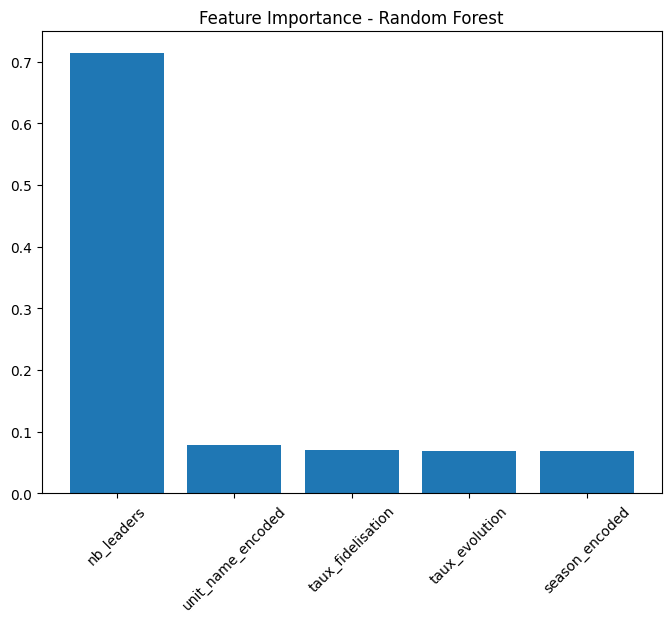

In [21]:
# --- 2. Implémentation  modèles linear et ridge
lin_reg = LinearRegression()
ridge_reg = Ridge(alpha=1.0)
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)

models = {
    "Linear Regression": lin_reg,
    "Ridge Regression": ridge_reg,
    "Random Forest": rf_reg
}

# Validation croisée et entraînement
kf = KFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    scores = cross_val_score(model, X_scaled, y, cv=kf, scoring="r2")
    print(f"{name} CV R² mean:", scores.mean())
    model.fit(X_train, y_train)
# Évaluation test set
for name, model in models.items():
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    print(f"\n{name} Results:")
    print("MSE:", mse)
    print("RMSE:", rmse)
    print("MAE:", mae)
    print("R²:", r2)
#  Visualisations  Résidus (erreurs)
plt.figure(figsize=(12,5))
for name, model in models.items():
    y_pred = model.predict(X_test)
    residuals = y_test - y_pred
    sns.scatterplot(x=y_pred, y=residuals, label=name)
plt.axhline(0, color="black", linestyle="--")
plt.xlabel("Predicted values")
plt.ylabel("Residuals")
plt.title("Residuals Plot Comparison")
plt.legend()
plt.show()

# Actual vs Predicted
plt.figure(figsize=(12,5))
for name, model in models.items():
    y_pred = model.predict(X_test)
    sns.scatterplot(x=y_test, y=y_pred, label=name)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "k--")
plt.xlabel("Actual values")
plt.ylabel("Predicted values")
plt.title("Actual vs Predicted Comparison")
plt.legend()
plt.show()

# Importance des features Random Forest uniquement
importances = rf_reg.feature_importances_
indices = np.argsort(importances)[::-1]
plt.figure(figsize=(8,6))
plt.bar(range(len(indices)), importances[indices], align="center")
plt.xticks(range(len(indices)), [X.columns[i] for i in indices], rotation=45)
plt.title("Feature Importance - Random Forest")
plt.show()


/tmp/ipykernel_482/2692933877.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(models, rotation=20)
/tmp/ipykernel_482/2692933877.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(models, rotation=20)
/tmp/ipykernel_482/2692933877.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(models, rotation=20)


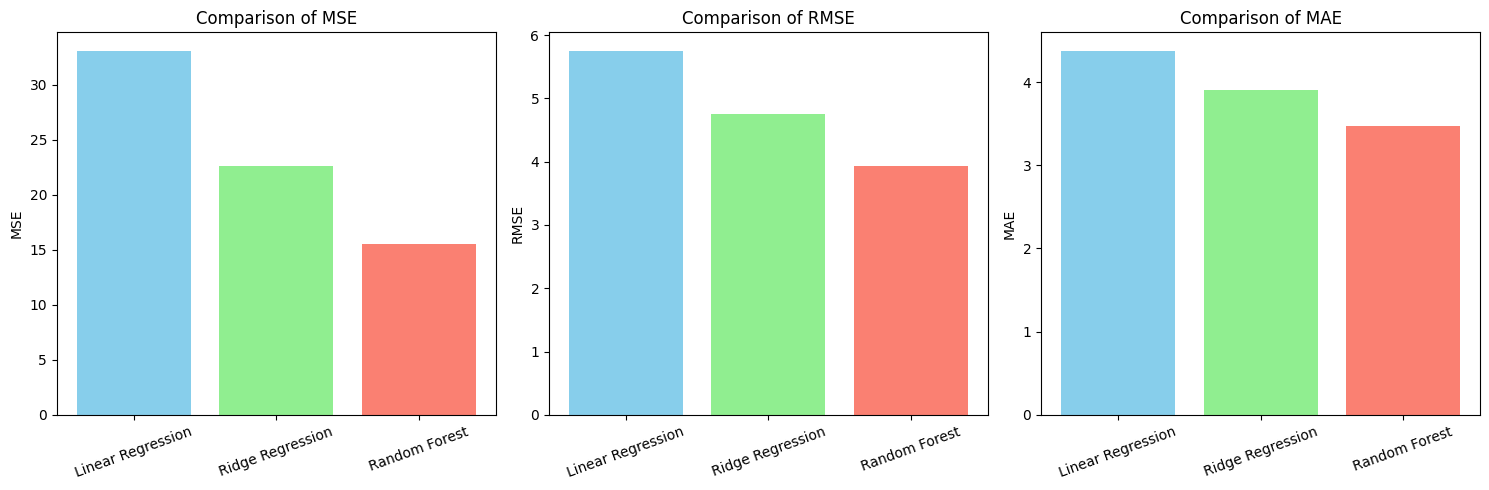

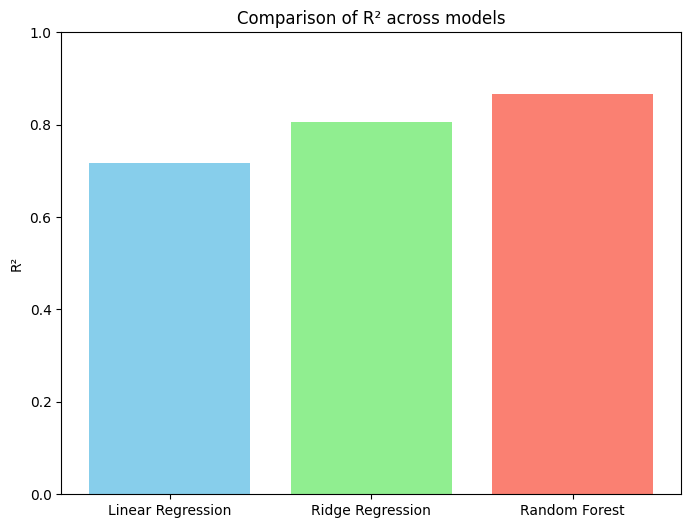

In [22]:
#comparaison avec visuels
import matplotlib.pyplot as plt
import numpy as np

results = {
    "Linear Regression": {"MSE": 33.1184, "RMSE": 5.7549, "MAE": 4.3783, "R2": 0.7162},
    "Ridge Regression": {"MSE": 22.6132, "RMSE": 4.7553, "MAE": 3.9092, "R2": 0.8062},
    "Random Forest": {"MSE": 15.5177, "RMSE": 3.9393, "MAE": 3.4700, "R2": 0.8670}
}

models = list(results.keys())
metrics = ["MSE", "RMSE", "MAE", "R2"]

values = {metric: [results[m][metric] for m in models] for metric in metrics}

#  Comparaison des erreurs (MSE, RMSE, MAE)
fig, ax = plt.subplots(1, 3, figsize=(15,5))

for i, metric in enumerate(["MSE", "RMSE", "MAE"]):
    ax[i].bar(models, values[metric], color=["skyblue","lightgreen","salmon"])
    ax[i].set_title(f"Comparison of {metric}")
    ax[i].set_ylabel(metric)
    ax[i].set_xticklabels(models, rotation=20)

plt.tight_layout()
plt.show()

# Comparaison du R²
plt.figure(figsize=(8,6))
plt.bar(models, values["R2"], color=["skyblue","lightgreen","salmon"])
plt.ylim(0,1)
plt.ylabel("R²")
plt.title("Comparison of R² across models")
plt.show()


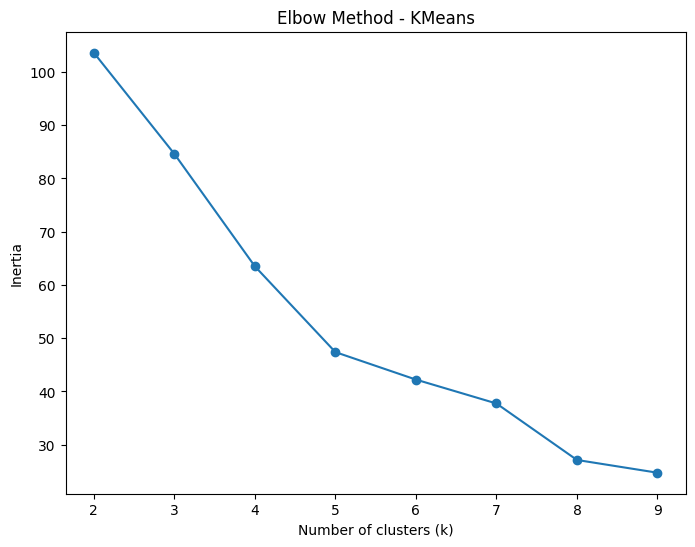

In [23]:

#  Clustering

import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

fact_membership = pd.read_csv("fact-membership.csv")
dim_unit = pd.read_csv("dim-unit.csv")

df = fact_membership.merge(dim_unit, on="id_unit", how="left")

encoder = LabelEncoder()
df["unit_name_encoded"] = encoder.fit_transform(df["unit_name"])
df["season_encoded"] = encoder.fit_transform(df["season"])

X = df[["nb_members", "nb_leaders", "taux_fidelisation", "taux_evolution",
        "unit_name_encoded", "season_encoded"]]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# K-Means avec Elbow method
inertia = []
K_range = range(2,10)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8,6))
plt.plot(K_range, inertia, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method - KMeans")
plt.show()


In [24]:

kmeans = KMeans(n_clusters=3, random_state=42)
labels_km = kmeans.fit_predict(X_scaled)

# DBSCAN
dbscan = DBSCAN(eps=1.5, min_samples=5)
labels_db = dbscan.fit_predict(X_scaled)

# Gaussian Mixture (GMM)
gmm = GaussianMixture(n_components=3, random_state=42)
labels_gmm = gmm.fit_predict(X_scaled)

#  Évaluation des clusters

def evaluate_clustering(X, labels, name):
    if len(set(labels)) > 1 and -1 not in labels:  # éviter cas trivial ou bruit DBSCAN
        sil = silhouette_score(X, labels)
        dbi = davies_bouldin_score(X, labels)
        print(f"{name} -> Silhouette: {sil:.3f}, Davies-Bouldin: {dbi:.3f}")
    else:
        print(f"{name} -> Clustering not valid (single cluster or noise only)")

evaluate_clustering(X_scaled, labels_km, "KMeans")
evaluate_clustering(X_scaled, labels_db, "DBSCAN")
evaluate_clustering(X_scaled, labels_gmm, "GMM")


KMeans -> Silhouette: 0.309, Davies-Bouldin: 0.980
DBSCAN -> Clustering not valid (single cluster or noise only)
GMM -> Silhouette: 0.309, Davies-Bouldin: 0.980


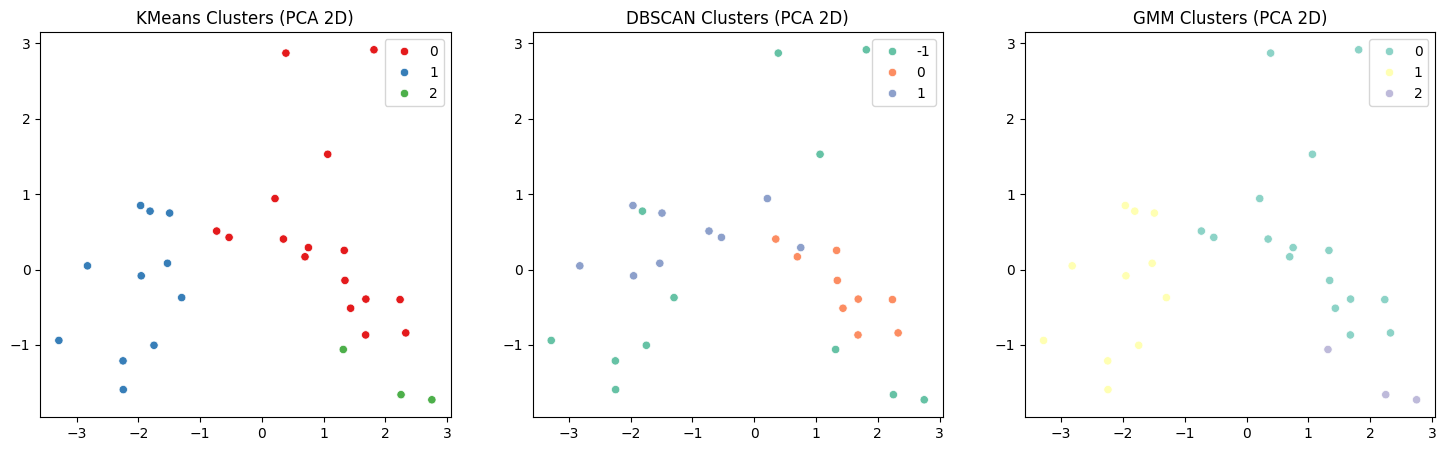

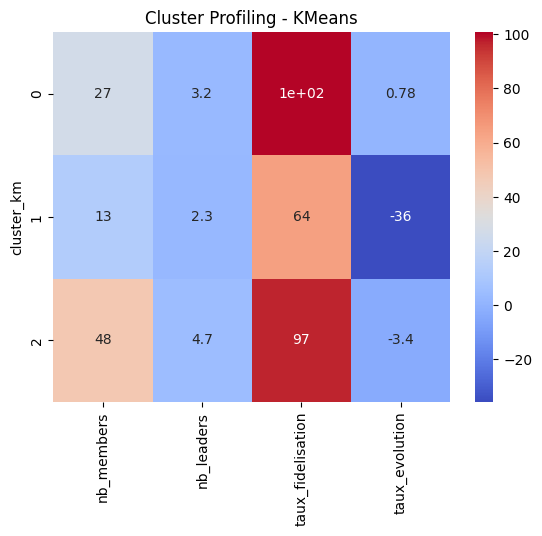

In [25]:
# Visualisation des clusters avec PCA 2D

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

fig, ax = plt.subplots(1,3, figsize=(18,5))

sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=labels_km, palette="Set1", ax=ax[0])
ax[0].set_title("KMeans Clusters (PCA 2D)")

sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=labels_db, palette="Set2", ax=ax[1])
ax[1].set_title("DBSCAN Clusters (PCA 2D)")

sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=labels_gmm, palette="Set3", ax=ax[2])
ax[2].set_title("GMM Clusters (PCA 2D)")

plt.show()

# Cluster profiling avec KMeans
df["cluster_km"] = labels_km
profile = df.groupby("cluster_km")[["nb_members","nb_leaders","taux_fidelisation","taux_evolution"]].mean()
sns.heatmap(profile, annot=True, cmap="coolwarm")
plt.title("Cluster Profiling - KMeans")
plt.show()


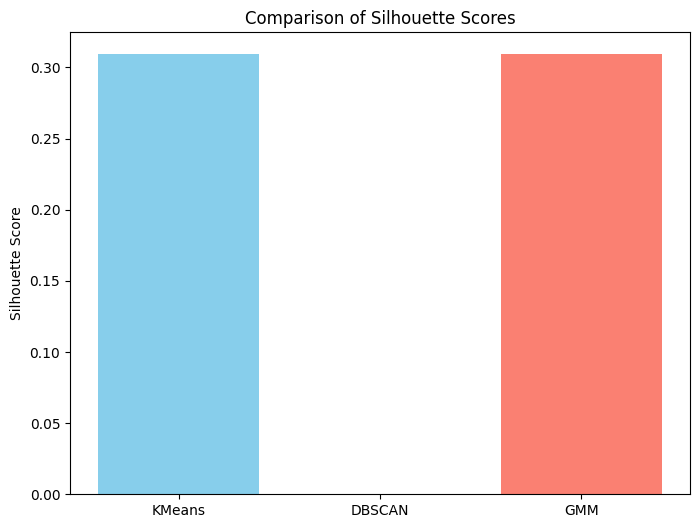

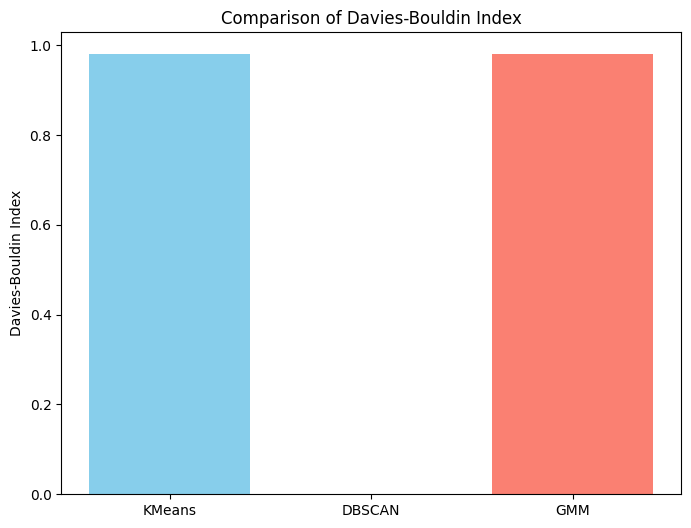

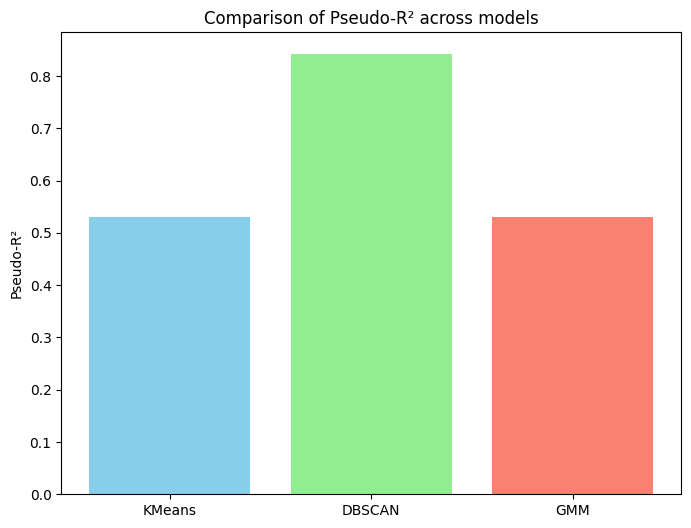

In [26]:
import numpy as np

def pseudo_r2(X, labels):
    # Moyenne globale
    overall_mean = np.mean(X, axis=0)
    # Somme des carrés totale
    ss_total = np.sum((X - overall_mean)**2)
    # Somme des carrés intra-cluster
    ss_within = 0
    for cluster in set(labels):
        if cluster == -1:  # ignorer bruit DBSCAN
            continue
        cluster_points = X[labels == cluster]
        cluster_mean = np.mean(cluster_points, axis=0)
        ss_within += np.sum((cluster_points - cluster_mean)**2)
    # Pseudo-R²
    return 1 - ss_within/ss_total

# Calcul des scores
scores = {
    "KMeans": {"Silhouette": silhouette_score(X_scaled, labels_km),
               "Davies-Bouldin": davies_bouldin_score(X_scaled, labels_km),
               "R2": pseudo_r2(X_scaled, labels_km)},
    "DBSCAN": {"Silhouette": silhouette_score(X_scaled, labels_db) if len(set(labels_db))>1 and -1 not in labels_db else 0,
               "Davies-Bouldin": davies_bouldin_score(X_scaled, labels_db) if len(set(labels_db))>1 and -1 not in labels_db else 0,
               "R2": pseudo_r2(X_scaled, labels_db)},
    "GMM": {"Silhouette": silhouette_score(X_scaled, labels_gmm),
            "Davies-Bouldin": davies_bouldin_score(X_scaled, labels_gmm),
            "R2": pseudo_r2(X_scaled, labels_gmm)}
}

models = list(scores.keys())
silhouette_vals = [scores[m]["Silhouette"] for m in models]
db_vals = [scores[m]["Davies-Bouldin"] for m in models]
r2_vals = [scores[m]["R2"] for m in models]

# Silhouette comparison
plt.figure(figsize=(8,6))
plt.bar(models, silhouette_vals, color=["skyblue","lightgreen","salmon"])
plt.ylabel("Silhouette Score")
plt.title("Comparison of Silhouette Scores")
plt.show()

#Davies-Bouldin comparison
plt.figure(figsize=(8,6))
plt.bar(models, db_vals, color=["skyblue","lightgreen","salmon"])
plt.ylabel("Davies-Bouldin Index")
plt.title("Comparison of Davies-Bouldin Index")
plt.show()

# R² comparison
plt.figure(figsize=(8,6))
plt.bar(models, r2_vals, color=["skyblue","lightgreen","salmon"])
plt.ylabel("Pseudo-R²")
plt.title("Comparison of Pseudo-R² across models")
plt.show()


RMSE: 4.4253367775293546e-14 MAE: 1.651186887156671e-14
Top recommendations for user 1 :
Activity 17 (Summer Camp Cubs Flowers 2025) -> predicted score 85.00
Activity 49 (General activities) -> predicted score 36.00
Activity 2 (Educational trips) -> predicted score 0.00
Activity 20 (Dalilat Summer Camp 2025) -> predicted score 0.00
Activity 3 (Environmental activities) -> predicted score 0.00


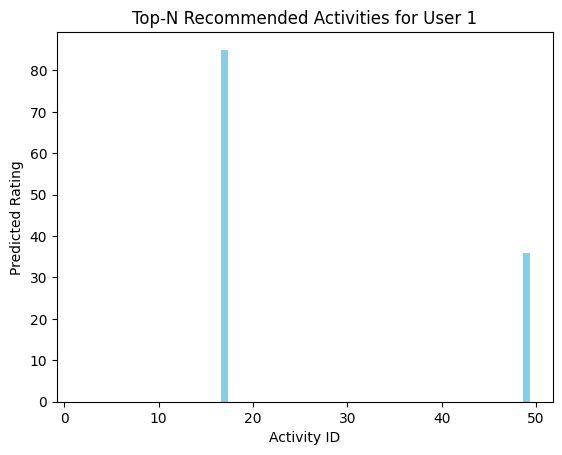

In [28]:
import pandas as pd
import numpy as np
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt

# Charger les données
dim_activity = pd.read_csv("dim-activity.csv")
fact_participation = pd.read_csv("fact-participation.csv")

# Construire la matrice user-item
ratings = fact_participation[["id_unit","id_activity","nb_participants"]].copy()
ratings.rename(columns={"id_unit":"user_id","id_activity":"item_id","nb_participants":"rating"}, inplace=True)
ratings = ratings[ratings["rating"] > 0]

# Créer une matrice utilisateur × activité
user_item_matrix = ratings.pivot_table(index="user_id", columns="item_id", values="rating").fillna(0)

# SVD
svd = TruncatedSVD(n_components=20, random_state=42)
latent_matrix = svd.fit_transform(user_item_matrix)

# Reconstruire la matrice prédite
pred_matrix = np.dot(latent_matrix, svd.components_)

# Évaluation
y_true = user_item_matrix.values.flatten()
y_pred = pred_matrix.flatten()
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)
print("RMSE:", rmse, "MAE:", mae)

# Recommandations pour un utilisateur
user_id = 1
user_index = user_item_matrix.index.get_loc(user_id)
pred_scores = pred_matrix[user_index]

recommendations = sorted(list(zip(user_item_matrix.columns, pred_scores)), key=lambda x: x[1], reverse=True)[:5]

print("Top recommendations for user", user_id, ":")
for act, score in recommendations:
    act_name = dim_activity.loc[dim_activity["id_activity"]==act, "activity_name_en"].values[0]
    print(f"Activity {act} ({act_name}) -> predicted score {score:.2f}")

# Visualisation
acts, scores = zip(*recommendations)
plt.bar(acts, scores, color="skyblue")
plt.xlabel("Activity ID")
plt.ylabel("Predicted Rating")
plt.title(f"Top-N Recommended Activities for User {user_id}")
plt.show()


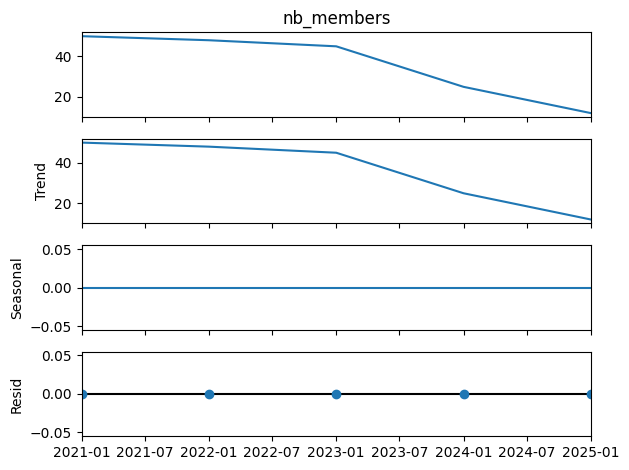

ADF Statistic: 0.6701450417058761
p-value: 0.9892228375714093
KPSS Statistic: 0.34291212315586916
p-value: 0.1


/tmp/ipykernel_482/3044826598.py:36: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_test = kpss(ts, regression="c")
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for ARMA and trend. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 2.
/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  dates = pd.date_rang

ARIMA -> MAE: 5.15, RMSE: 5.15, MAPE: 42.95%
Prophet -> MAE: 9.49, RMSE: 9.49, MAPE: 79.09%


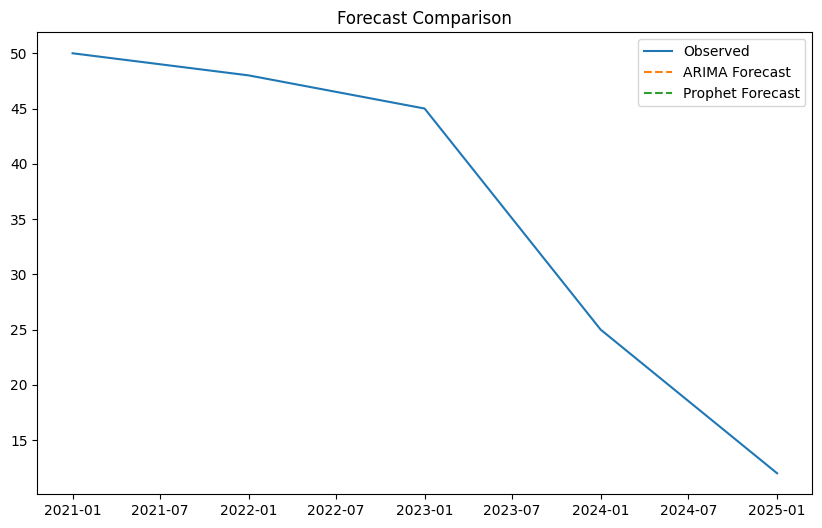

In [29]:

# Time Series Forecasting


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error

df = pd.read_csv("fact-membership.csv")

#  choisir une série temporelle nb_members par saison pour une unité
unit_id = 1
ts = df[df["id_unit"]==unit_id].set_index("season")["nb_members"]

# Convertir saison en index temporel
ts.index = pd.period_range(start="2021", periods=len(ts), freq="Y")
ts = ts.to_timestamp()

# Analyse stationnarité et décomposition
result = seasonal_decompose(ts, model="additive", period=1)
result.plot()
plt.show()

# Test ADF
adf_test = adfuller(ts)
print("ADF Statistic:", adf_test[0])
print("p-value:", adf_test[1])

# Test KPSS
kpss_test = kpss(ts, regression="c")
print("KPSS Statistic:", kpss_test[0])
print("p-value:", kpss_test[1])

#Modèle ARIMA
train_size = int(len(ts)*0.8)
train, test = ts[:train_size], ts[train_size:]

arima_model = ARIMA(train, order=(1,1,1))
arima_fit = arima_model.fit()
arima_forecast = arima_fit.forecast(steps=len(test))

# Modèle Prophet
prophet_df = ts.reset_index()
prophet_df.columns = ["ds","y"]

train_prophet = prophet_df.iloc[:train_size]
test_prophet = prophet_df.iloc[train_size:]

prophet_model = Prophet()
prophet_model.fit(train_prophet)

future = prophet_model.make_future_dataframe(periods=len(test_prophet), freq="Y")
forecast = prophet_model.predict(future)

prophet_forecast = forecast.iloc[-len(test_prophet):]["yhat"].values

#Évaluation
def evaluate(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred)/y_true))*100
    print(f"{model_name} -> MAE: {mae:.2f}, RMSE: {rmse:.2f}, MAPE: {mape:.2f}%")

evaluate(test.values, arima_forecast.values, "ARIMA")
evaluate(test_prophet["y"].values, prophet_forecast, "Prophet")

# Visualisation
plt.figure(figsize=(10,6))
plt.plot(ts.index, ts.values, label="Observed")
plt.plot(test.index, arima_forecast, label="ARIMA Forecast", linestyle="--")
plt.plot(test_prophet["ds"], prophet_forecast, label="Prophet Forecast", linestyle="--")
plt.legend()
plt.title("Forecast Comparison")
plt.show()


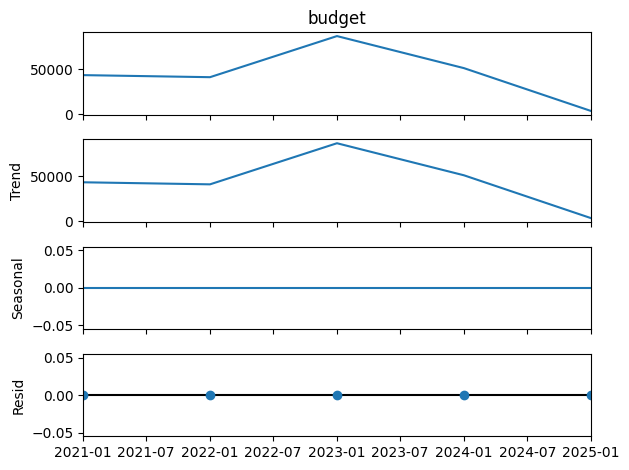

/tmp/ipykernel_482/3485122453.py:34: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  print("KPSS:", kpss(budget_series["budget"], regression="c"))
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observa

ADF: (np.float64(-0.9970041384872738), np.float64(0.754355403890258), 0, 4, {'1%': np.float64(-7.355440625), '5%': np.float64(-4.474365000000001), '10%': np.float64(-3.1269325)}, np.float64(97.6970188573841))
KPSS: (np.float64(0.17326553880444717), np.float64(0.1), 0, {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739})


INFO:prophet:n_changepoints greater than number of observations. Using 2.
/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  dates = pd.date_range(


ARIMA -> MAE: 72855.28, RMSE: 72855.28, MAPE: 2142.80%
Prophet -> MAE: 62287.99, RMSE: 62287.99, MAPE: 1832.00%


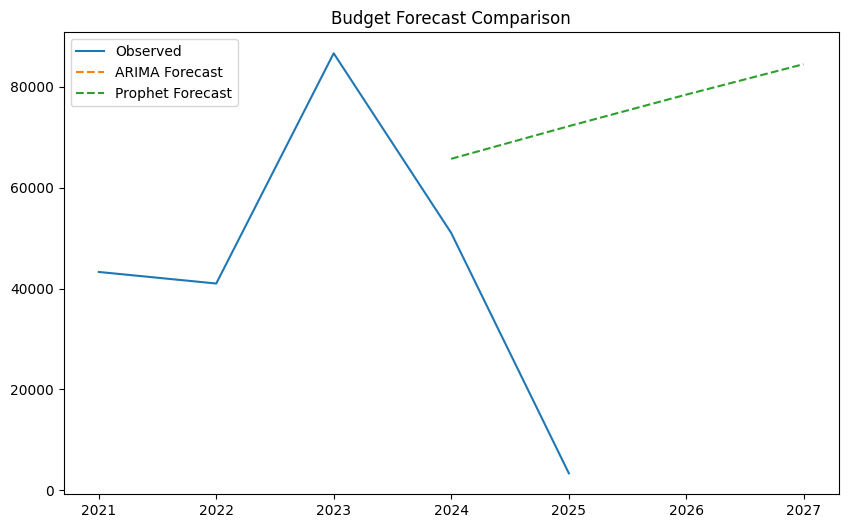

Future budget predictions:
          ds          yhat
4 2024-12-31  72146.402487
5 2025-12-31  78394.927585
6 2026-12-31  84432.424958


In [33]:
#serie budget

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error

df = pd.read_csv("fact-budget.csv")

# Budget total par saison
budget_series = df.groupby("season")["amount"].sum().reset_index()

# Extraire la première année de la saison "2021/2022" -> 2021
budget_series["year"] = budget_series["season"].str.split("/").str[0].astype(int)

# Créer une colonne date (année au 1er janvier)
budget_series["date"] = pd.to_datetime(budget_series["year"], format="%Y")

# Préparer la série
budget_series = budget_series.rename(columns={"amount":"budget"})
budget_series.set_index("date", inplace=True)

# Analyse stationnarité et décomposition
result = seasonal_decompose(budget_series["budget"], model="additive", period=1)
result.plot()
plt.show()

# Tests ADF/KPSS
print("ADF:", adfuller(budget_series["budget"]))
print("KPSS:", kpss(budget_series["budget"], regression="c"))

train_size = int(len(budget_series)*0.8)
train, test = budget_series.iloc[:train_size], budget_series.iloc[train_size:]

# ARIMA
arima_model = ARIMA(train["budget"], order=(1,1,1))
arima_fit = arima_model.fit()
arima_forecast = arima_fit.forecast(steps=len(test))

# Prophet
prophet_df = budget_series.reset_index()[["date","budget"]]
prophet_df.columns = ["ds","y"]

train_prophet = prophet_df.iloc[:train_size]
test_prophet = prophet_df.iloc[train_size:]

prophet_model = Prophet(yearly_seasonality=True)
prophet_model.fit(train_prophet)

# Prévoir 3 saisons futures (2026, 2027, 2028)
future = prophet_model.make_future_dataframe(periods=3, freq="Y")
forecast = prophet_model.predict(future)

prophet_forecast = forecast[["ds","yhat"]].iloc[-(len(test_prophet)+3):]

#  Évaluation
def evaluate(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred)/y_true))*100
    print(f"{model_name} -> MAE: {mae:.2f}, RMSE: {rmse:.2f}, MAPE: {mape:.2f}%")

evaluate(test["budget"].values, arima_forecast.values, "ARIMA")
evaluate(test_prophet["y"].values, prophet_forecast["yhat"].values[:len(test_prophet)], "Prophet")

#  Visualisation
plt.figure(figsize=(10,6))
plt.plot(budget_series.index, budget_series["budget"], label="Observed")
plt.plot(test.index, arima_forecast, label="ARIMA Forecast", linestyle="--")
plt.plot(prophet_forecast["ds"], prophet_forecast["yhat"], label="Prophet Forecast", linestyle="--")
plt.legend()
plt.title("Budget Forecast Comparison")
plt.show()

# Prévisions futures (saisons 2026/2027, 2027/2028, 2028/2029)
future_predictions = prophet_forecast.tail(3)
print("Future budget predictions:")
print(future_predictions)


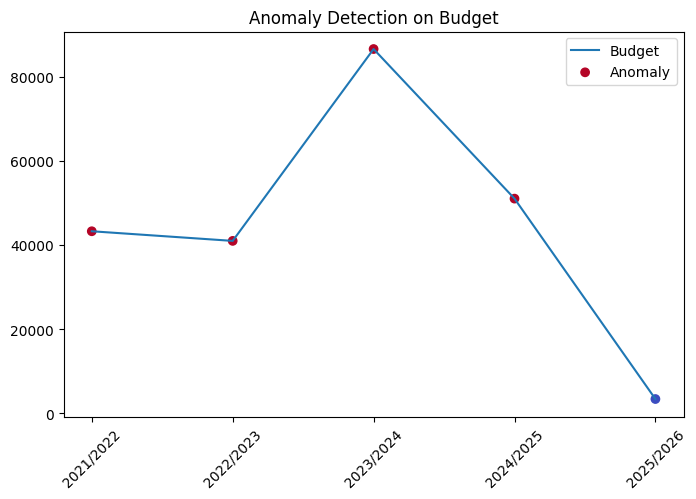

      season  amount  anomaly
0  2021/2022   43280        1
1  2022/2023   40990        1
2  2023/2024   86600        1
3  2024/2025   51039        1
4  2025/2026    3400       -1


In [34]:
#anomaliy detection
import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt

df = pd.read_csv("fact-budget.csv")

# Budget total par saison
budget_series = df.groupby("season")["amount"].sum().reset_index()

# Isolation Forest
iso = IsolationForest(contamination=0.1, random_state=42)
budget_series["anomaly"] = iso.fit_predict(budget_series[["amount"]])

# Visualisation
plt.figure(figsize=(8,5))
plt.plot(budget_series["season"], budget_series["amount"], label="Budget")
plt.scatter(budget_series["season"], budget_series["amount"],
            c=budget_series["anomaly"], cmap="coolwarm", label="Anomaly")
plt.xticks(rotation=45)
plt.legend()
plt.title("Anomaly Detection on Budget")
plt.show()

# Résultats
print(budget_series)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 267ms/step


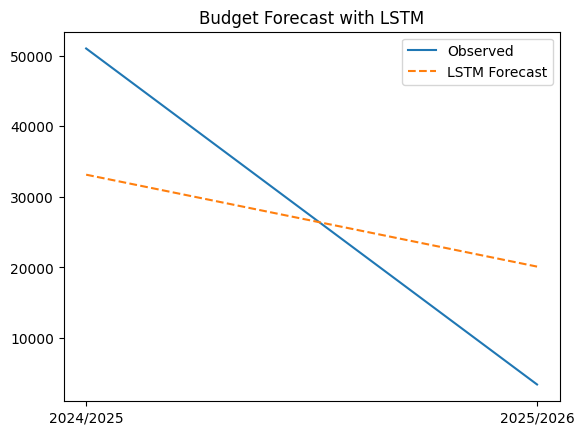

In [35]:
# deep LSTM (Long Short-Term Memory)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler

df = pd.read_csv("fact-budget.csv")
budget_series = df.groupby("season")["amount"].sum().reset_index()

# Prétraitement
scaler = MinMaxScaler()
budget_scaled = scaler.fit_transform(budget_series[["amount"]])

# Créer séquences (X, y)
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data)-seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

seq_length = 3
X, y = create_sequences(budget_scaled, seq_length)

# Reshape pour LSTM [samples, timesteps, features]
X = X.reshape((X.shape[0], X.shape[1], 1))

# Modèle LSTM
model = Sequential()
model.add(LSTM(50, activation='relu', input_shape=(seq_length,1)))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse')

# Entraînement
model.fit(X, y, epochs=200, verbose=0)

# Prédictions
predictions = model.predict(X)
predictions_rescaled = scaler.inverse_transform(predictions)

# Visualisation
plt.plot(budget_series["season"][seq_length:], budget_series["amount"][seq_length:], label="Observed")
plt.plot(budget_series["season"][seq_length:], predictions_rescaled, label="LSTM Forecast", linestyle="--")
plt.legend()
plt.title("Budget Forecast with LSTM")
plt.show()
